In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , LabelEncoder, StandardScaler

In [52]:
df= pd.read_csv("C:\\Users\\User\\Desktop\\python\\deeplearing\\work_from_home_burnout_dataset (1).csv")
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [53]:
categorical_binary=["burnout_risk"]
categorical_multi = ["day_type"]

In [54]:
num = ["work_hours"	,'screen_time_hours','meetings_count','breaks_taken','after_hours_work'	,'sleep_hours','task_completion_rate',"burnout_score"]

In [55]:
label_enc=LabelEncoder()
for col in categorical_binary:
 df[col] = label_enc.fit_transform(df[col])
 

In [56]:
df=pd.get_dummies(df,columns=[col for col in categorical_multi if col in df.columns], 
                    drop_first=True)


In [57]:
df.columns

Index(['user_id', 'work_hours', 'screen_time_hours', 'meetings_count',
       'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk',
       'day_type_Weekend'],
      dtype='object')

In [ ]:
x= df[['work_hours', 'screen_time_hours', 'meetings_count',
       'breaks_taken', 'after_hours_work', 'sleep_hours']]
y= df[['burnout_score', 'burnout_risk']]

In [59]:
x_train , x_test ,y_train ,y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [60]:
y_train = y_train.values.argmax(axis=1)
y_test = y_test.values.argmax(axis=1)

In [61]:
scaler =StandardScaler()
scaler.fit_transform(x_train)
scaler.transform(x_test)

array([[ 0.27223381,  0.74282965,  0.6145596 , -0.02638865, -0.74841834,
        -0.26090023],
       [-0.71135492, -0.53368126, -0.56225666, -0.73008599,  1.33615112,
        -0.62170847],
       [-1.13786685, -1.3501509 ,  0.02615147, -1.43378334,  1.33615112,
         0.19485755],
       ...,
       [-1.52520931, -1.85578184, -0.56225666, -1.43378334, -0.74841834,
        -1.09645615],
       [ 0.99904495,  0.77598578,  0.02615147, -1.43378334, -0.74841834,
         0.21384746],
       [-0.78534168, -1.26311606, -0.56225666, -0.02638865,  1.33615112,
         1.77101986]], shape=(360, 6))

In [62]:
model = Sequential([Dense( 3, activation= "softmax", input_dim = x_test.shape[1])])

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
from sklearn.compose import ColumnTransformer 

In [64]:
model.compile(loss="sparse_categorical_crossentropy", optimizer= Adam(00.1), metrics= ['accuracy'])

In [65]:
history = model.fit(x_train,y_train ,epochs=10 ,batch_size=11, validation_split=0.2)

Epoch 1/10


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9887 - loss: 0.0502 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy:

In [66]:
model.compile(loss= "mse", optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=3, validation_split=0.2)

Epoch 1/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 2/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 3/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 4/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 5/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 6/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 7/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.0000 - val_loss: 0.3333
Epoch 8/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.3333 - val_accuracy: 1.

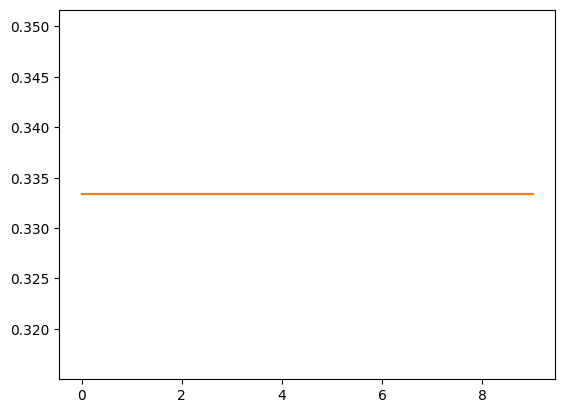

In [67]:
plt.plot(history.history["val_loss"],label =" validation"  )
plt.plot(history.history["loss"],label = "loss")
plt.show()